In [22]:
import rasterio
from pathlib import Path

filename = "dw_-55.0649747732_4.9885733865-20190902"

folder_path = Path("data/processed")

tci_path = list((folder_path / "tci").rglob(f"{filename}.tif"))[0]
data_path = list((folder_path / "input").rglob(f"{filename}.tif"))[0]
mask_path = list((folder_path / "mask").rglob(f"{filename}.tif"))[0]
label_path = list(Path("data/dynamicworld_extracted").rglob(f"{filename}.tif"))[0]

with rasterio.open(tci_path) as src:
    tci = src.read()
    
with rasterio.open(data_path) as src:
    data = src.read()

with rasterio.open(mask_path) as src:
    mask = src.read()

with rasterio.open(label_path) as src:
    label = src.read()

print("TCI shape:", tci.shape)
print("Data shape:", data.shape)
print("Mask shape:", mask.shape)
print("Label shape:", label.shape)

TCI shape: (3, 510, 510)
Data shape: (9, 510, 510)
Mask shape: (1, 510, 510)
Label shape: (1, 510, 510)


In [23]:
import rasterio
from pprint import pprint

filename = "label_dw_-3p9589394764_15p8586613852-20191114"
test_path = list(Path("data/dynamicworld_extracted").rglob(f"{filename}.tif"))[0]

with rasterio.open(data_path) as src:
    test = src.read()  # your existing read

    print("=== Basic Identity ===")
    print("name:", src.name)
    print("driver:", src.driver)          # should be GTiff
    print("closed:", src.closed)
    print("mode:", src.mode)

    print("\n=== Raster Shape ===")
    print("width, height:", src.width, src.height)
    print("band count:", src.count)
    print("dtypes:", src.dtypes)
    print("indexes:", src.indexes)
    print("shape (bands, rows, cols):", test.shape)

    print("\n=== Geo Metadata ===")
    print("crs:", src.crs)
    print("transform:", src.transform)
    print("bounds:", src.bounds)
    print("resolution:", src.res)
    print("nodata:", src.nodata)
    print("nodatavals:", src.nodatavals)

    print("\n=== Full meta/profile ===")
    pprint(src.meta)
    pprint(src.profile)

    print("\n=== Dataset tags ===")
    pprint(src.tags())
    print("tag namespaces:", src.tag_namespaces())
    for ns in src.tag_namespaces():
        print(f"namespace {ns}:")
        pprint(src.tags(ns=ns))

    print("\n=== Per-band tags & overviews ===")
    for b in src.indexes:
        print(f"\nBand {b}:")
        pprint(src.tags(b))
        print("overviews:", src.overviews(b))

=== Basic Identity ===
name: data/processed/input/dw_-55.0649747732_4.9885733865-20190902.tif
driver: GTiff
closed: False
mode: r

=== Raster Shape ===
width, height: 510 510
band count: 9
dtypes: ('float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32', 'float32')
indexes: (1, 2, 3, 4, 5, 6, 7, 8, 9)
shape (bands, rows, cols): (9, 510, 510)

=== Geo Metadata ===
crs: EPSG:32621
transform: | 10.00, 0.00, 712010.00|
| 0.00,-10.00, 554260.00|
| 0.00, 0.00, 1.00|
bounds: BoundingBox(left=712010.0, bottom=549160.0, right=717110.0, top=554260.0)
resolution: (10.0, 10.0)
nodata: None
nodatavals: (None, None, None, None, None, None, None, None, None)

=== Full meta/profile ===
{'count': 9,
 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 21N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9

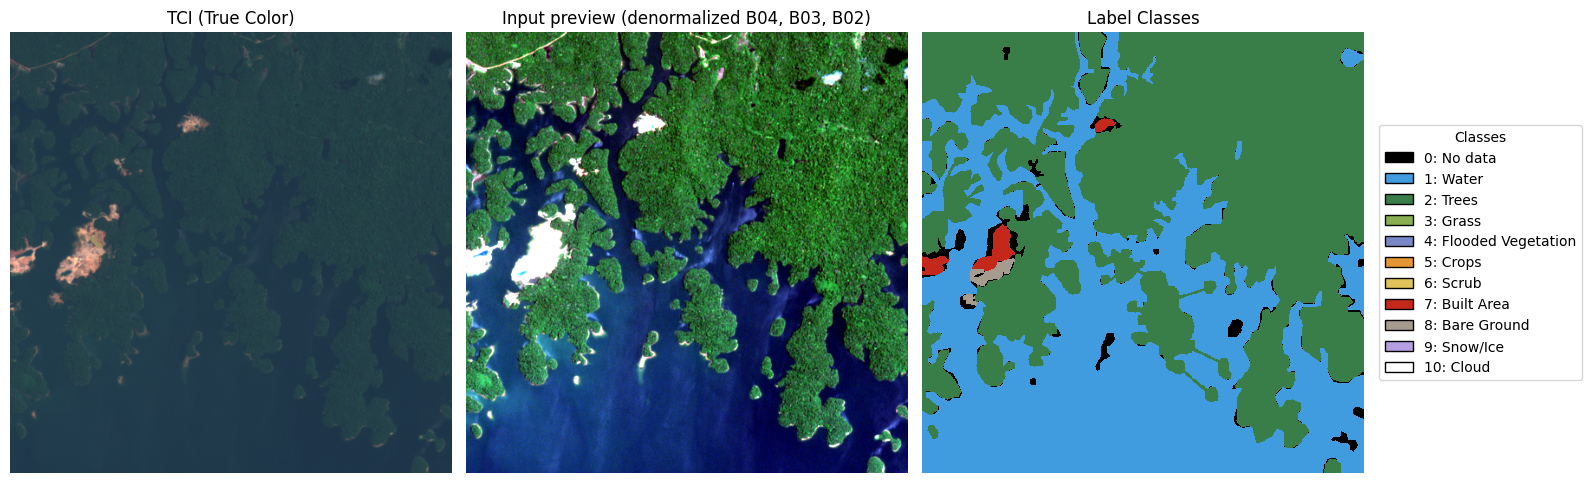

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
import rasterio


tci_vis = np.moveaxis(tci[:3], 0, -1)


# Reconstruct a display RGB from the first three bands (B02, B03, B04).
norm_percentiles = np.array([
    [1.7417268007636313, 2.023298706048351],   # B02
    [1.7261204997060209, 2.038905204308012],   # B03
    [1.6798346251414997, 2.179592821212937],   # B04
])

input_rgb = data[:3].astype(np.float32)
input_rgb = np.where(np.isfinite(input_rgb), input_rgb, np.nan)

input_vis = np.moveaxis(input_rgb[[2, 1, 0]], 0, -1)

# Stretch each channel using only valid (finite) pixels.
input_vis = input_vis.astype(np.float32)
for i in range(3):
    band = input_vis[..., i]
    valid = np.isfinite(band)
    if valid.any():
        low = np.nanpercentile(band[valid], 2)
        high = np.nanpercentile(band[valid], 98)
        band = np.clip((band - low) / max(high - low, 1e-6), 0, 1)
        band = np.nan_to_num(band, nan=0.0)
    else:
        band = np.zeros_like(band)
    input_vis[..., i] = band

# --- Label visualization with class colormap + legend ---
label2d = label[0] if label.ndim == 3 else label
label2d = label2d.astype(np.int32)

class_names = [
    "No data",           # 0
    "Water",             # 1
    "Trees",             # 2
    "Grass",             # 3
    "Flooded Vegetation",# 4
    "Crops",             # 5
    "Scrub",             # 6
    "Built Area",        # 7
    "Bare Ground",       # 8
    "Snow/Ice",          # 9
    "Cloud"              # 10
]

class_colors = [
    "#000000", # No data (Black)
    "#419BDF", # Water
    "#397D49", # Trees
    "#88B053", # Grass
    "#7A87C6", # Flooded vegetation
    "#E49635", # Crops
    "#DFC35A", # Scrub (New in this schema)
    "#C4281B", # Built Area
    "#A59B8F", # Bare Ground
    "#B39FE1", # Snow and ice
    "#FFFFFF"  # Cloud
]

# When the researchers (Google, NatGeo, WRI) prepared the final paper and the public "Dynamic World" product, 
# they realized that the AI and humans often confused "Scrub" with "Shrub" or "Bare."

cmap = ListedColormap(class_colors)
norm = BoundaryNorm(np.arange(-0.5, len(class_colors) + 0.5, 1), cmap.N)

fig, axes = plt.subplots(1, 3, figsize=(16, 12))
axes = axes.ravel()

axes[0].imshow(tci_vis)
axes[0].set_title("TCI (True Color)")
axes[0].axis("off")

axes[1].imshow(input_vis)
axes[1].set_title("Input preview (denormalized B04, B03, B02)")
axes[1].axis("off")

axes[2].imshow(label2d, cmap=cmap, norm=norm, interpolation="nearest")
axes[2].set_title("Label Classes")
axes[2].axis("off")

legend_handles = [
    Patch(facecolor=class_colors[i], edgecolor="black", label=f"{i}: {class_names[i]}")
    for i in range(len(class_names))
]
axes[2].legend(
    handles=legend_handles,
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=True,
    title="Classes",
)

plt.tight_layout()
plt.show()

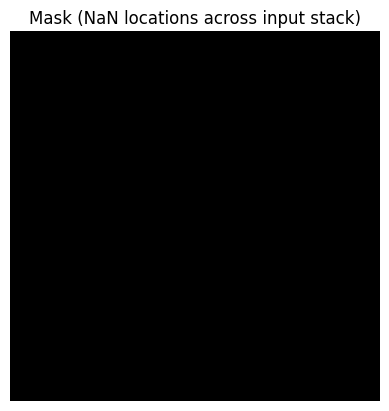

In [25]:
# Mask panel: NaN locations across the input stack.
mask_vis = mask.reshape(mask.shape[1], mask.shape[2]).astype(np.uint8)

plt.imshow(mask_vis, cmap="gray")
plt.title("Mask (NaN locations across input stack)")
plt.axis("off")

plt.show() # blac = clear, white = masked